## Evaluating predictions on testing data

In [1]:
import sys
import importlib as imp
import math
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from rasterio.windows import Window
from sklearn.metrics import mean_squared_error, mean_absolute_error

from utils import utils
from visualizer import plots
from analyzer import analyze_predictions
from data_builder import data_methods

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"pytorch version = {torch.__version__}")

python version = 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:36:57) [Clang 15.0.7 ]
numpy version = 1.26.4
pytorch version = 2.1.2.post3


In [3]:
# GET config
EXP_NAME = "exp312"

config = utils.get_config(EXP_NAME)
config["mode"] = "inference"
directory_paths = utils.get_directories(config["machine"])

 --- 2020---
-40.0 50 -100 150.0
-40.00108128655818 49.999330398808446 -99.9986607976169 150.0006861422768
(64182620,) (64182620,)


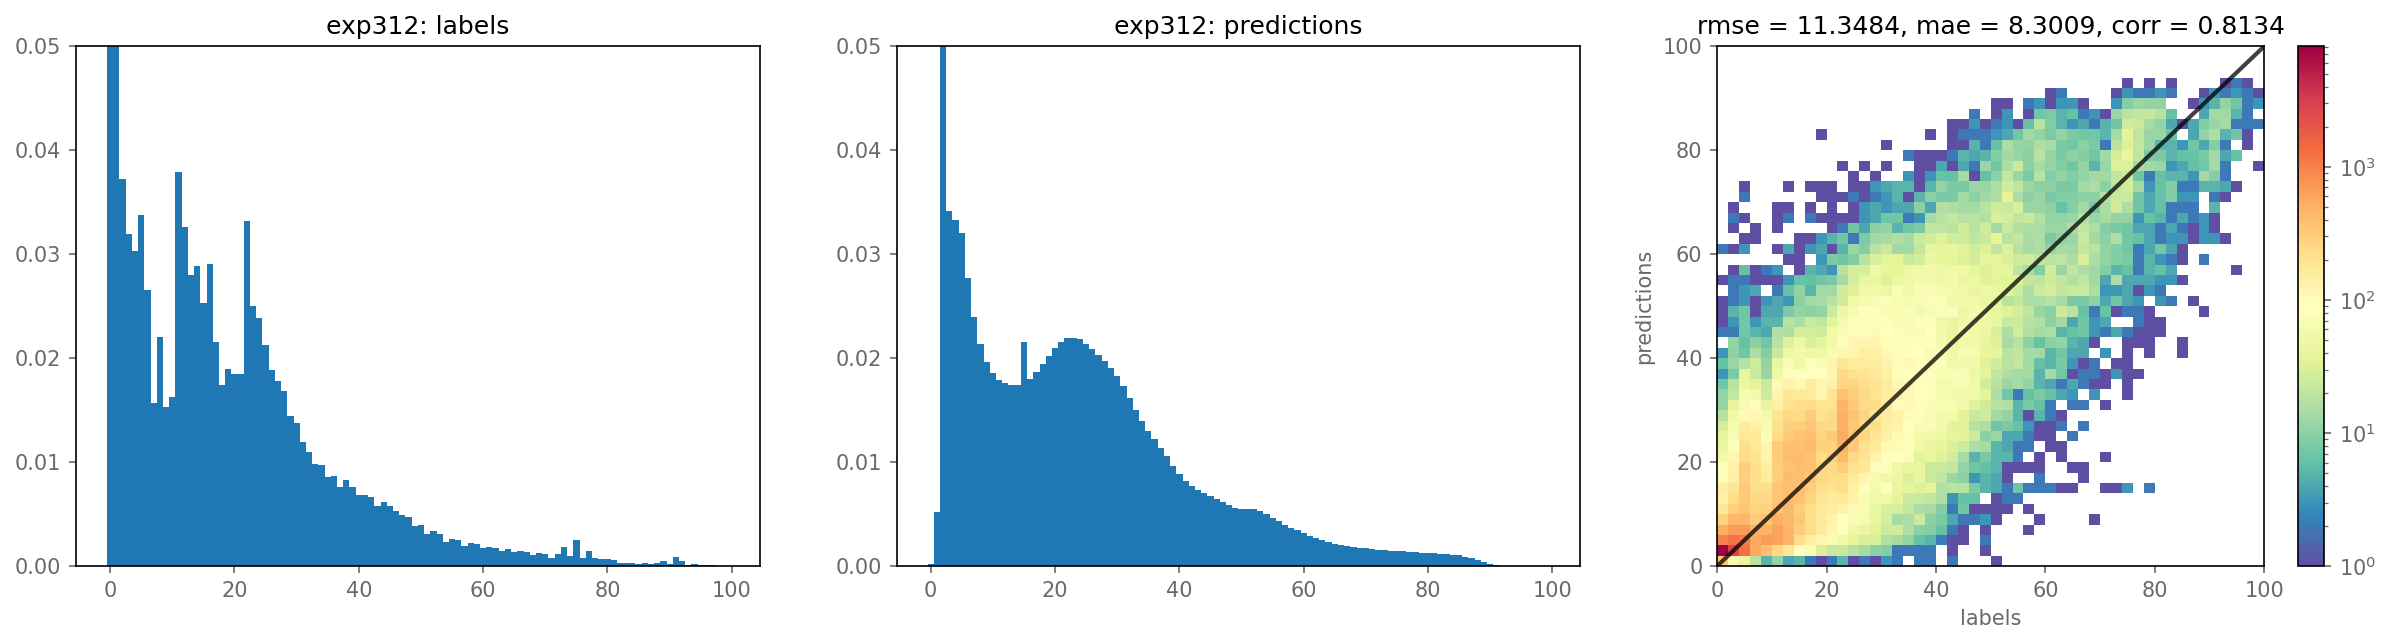

In [4]:
nsamples_to_plot = 100_000

for year in (2020,):
    print(" --- " + str(year) + "---")
    config["inference_years"] = (year,)

    # TILE THE PREDICTIONS TOGETHER
    model_name = utils.get_model_name(config["expname"], config["seed"])
    mosaic_filename = (
        directory_paths["mosaics_dir"]
        + model_name
        + "_"
        + str(config["inference_years"][0])
        + "_mlhfi_mosaic.tif"
    )
    labels_filename = (
        directory_paths["data_dir"]
        + "hii_"
        + str(config["inference_years"][0])
        + "-01-01_uint8.tif"
    )

    with rasterio.open(mosaic_filename) as predict_tif:

        if isinstance(config["data"]["inference_region"], dict):
            lat_s, lat_n, lon_w, lon_e = data_methods.get_region_bounds(
                region=config["data"]["inference_region"],
                tile_len_deg=config["tile_len_deg"],
            )
        else:
            lat_s, lat_n, lon_w, lon_e = config["data"]["inference_region"]
        # lon_w, lat_s, lon_e, lat_n = predict_tif.bounds
        print(lat_s, lat_n, lon_w, lon_e)

        ilat_n, ilon_w = predict_tif.index(lon_w, lat_n, op=np.ceil)
        ilat_s, ilon_e = predict_tif.index(lon_e, lat_s, op=np.ceil)
        # ilat_n, ilon_w = max(ilat_n, 0), max(ilon_w, 0)

        window = Window.from_slices((ilat_n, ilat_s + 1), (ilon_w, ilon_e + 1))
        predictions = np.asarray(predict_tif.read(1, window=window), dtype="float")

        with rasterio.open(labels_filename) as label_tif:

            # get correct bounds to evaluate the labels
            lon_w, lat_n = predict_tif.xy(ilat_n, ilon_w, offset="ul")
            lon_e, lat_s = predict_tif.xy(ilat_s, ilon_e, offset="ul")
            ilat_n, ilon_w = label_tif.index(lon_w, lat_n, op=np.floor)
            ilat_s, ilon_e = label_tif.index(lon_e, lat_s, op=np.floor)

            print(lat_s, lat_n, lon_w, lon_e)
            window = Window.from_slices((ilat_n, ilat_s + 1), (ilon_w, ilon_e + 1))
            labels = np.asarray(label_tif.read(1, window=window), dtype="float")

    labels = labels[:-1, :]
    # ALIGN and PROCESS PREDICTIONS FOR ANALYAIS
    labels, predictions = analyze_predictions.process_flatten(
        config, labels, predictions, remove_edges=True
    )

    # %%
    # MAKE HISTOGRAMS
    plt.figure(figsize=(20, 4.5))
    plt.subplot(1, 3, 1)
    bins = np.arange(-0.5, 100.5, 1)
    plt.hist(labels, bins, density=True)
    plt.title(config["expname"] + ": labels")
    plt.ylim(0, 0.05)

    plt.subplot(1, 3, 2)
    bins = np.arange(-0.5, 100.5, 1)
    plt.hist(predictions, bins, density=True)
    plt.title(config["expname"] + ": predictions")
    plt.ylim(0, 0.05)

    # MAKE SUMMARY FIGURE
    rmse = np.sqrt(mean_squared_error(labels, predictions)).round(4)
    mae = mean_absolute_error(labels, predictions).round(4)
    corr = np.corrcoef(labels, predictions)[0, 1].round(4)

    rng = np.random.default_rng(42)
    iplot = rng.choice(np.arange(len(predictions)), size=nsamples_to_plot)

    plt.subplot(1, 3, 3)
    inc = 2
    plt.hist2d(
        x=labels[iplot],
        y=predictions[iplot],
        density=False,
        norm="log",
        bins=np.arange(0, 100 + inc, inc),
        cmap="Spectral_r",
        vmin=1,
    )
    plt.colorbar()
    plt.plot((0, 100), (0, 100), "-", linewidth=2, color="k", alpha=0.75)
    plt.title(f"{rmse = }, {mae = }, {corr = }")
    plt.xlabel("labels")
    plt.ylabel("predictions")
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plots.savefig(config, str(year) + "_prediction_metrics")
    plt.show()

In [5]:
label_tif.index?

Signature:
label_tif.index(
    x,
    y,
    z=None,
    op=<built-in function floor>,
    precision=None,
    transform_method=<TransformMethod.affine: 'transform'>,
    **rpc_options,
)
Docstring:
Get the (row, col) index of the pixel containing (x, y).

Parameters
----------
x : float
    x value in coordinate reference system
y : float
    y value in coordinate reference system
z : float, optional
    Height associated with coordinates. Primarily used for RPC based
    coordinate transformations. Ignored for affine based
    transformations. Default: 0.
op : function, optional (default: math.floor)
    Function to convert fractional pixels to whole numbers (floor,
    ceiling, round)
transform_method: TransformMethod, optional
    The coordinate transformation method. Default: `TransformMethod.affine`.
rpc_options: dict, optional
    Additional arguments passed to GDALCreateRPCTransformer
precision : int, optional
    This parameter is unused, deprecated in rasterio 1.3.0, and
   